In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier




# OLS
⭐ Ordinary Least Squares (OLS) Estimation — Full Explanation (Beginner Friendly)

OLS is the core method used to calculate the best-fit line in Linear Regression.

✅ 1. What is OLS? (Simple Explanation)
OLS finds the best straight line through the data such that:

📌 The sum of squared errors (distance from each point to the line) is minimum.

That’s why it is called:
Ordinary → basic version
Least → minimum
Squares → square of the errors
Estimation → estimating model parameters

🎯 2. Goal of OLS

If the line is:  y=mx+c
OLS finds m (slope) and c (intercept) such that:   Total Error=∑(ytrue​−ypredicted​)^2   is minimum;

This is why it's also called Minimizing the cost function.

📏 3. Why Squares?
Because:
Squaring removes negative signs
Makes errors bigger → model learns better
Gives differentiable (smooth) function → can calculate minimum

🧮 4. Formula for OLS (Simple Version)

If we have dataset:
(x₁, y₁), (x₂, y₂), … (xₙ, yₙ)
Slope (m):
         m=n∑xy−(∑x)(∑y)​ /( n∑x^2-(∑x)^ )
Intercept (c):
        c=yˉ​−mxˉ


💡 5. Intuition Behind OLS

For each data point:
Error = Actual - Predicted

OLS tries all possible lines and picks the one where:
Sum of squared errors is minimum.

This is equivalent to drawing many lines and picking the “best fit”.




In [ ]:
data = {
    'experience': [1,2,3,4,5,6,7,8,9,10],
    'salary':     [30,35,40,45,50,55,60,65,70,75]
}

df = pd.DataFrame(data)
print(df)

   experience  salary
0           1      30
1           2      35
2           3      40
3           4      45
4           5      50
5           6      55
6           7      60
7           8      65
8           9      70
9          10      75


In [ ]:
# 🔍 7. OLS Step-by-Step Implementation WITHOUT SKLEARN (manual OLS)
# Step 1: Extract x and y

x = np.array(df['experience'])
y = np.array(df['salary'])

n = len(x)

# Step 2: Calculate slope (m)
m = (n*np.sum(x*y) - np.sum(x)*np.sum(y)) / (n*np.sum(x**2) - (np.sum(x))**2)

# Step 3: Calculate intercept (c)
c = (np.sum(y) - m*np.sum(x)) / n

# Step 4: Final equation
print("Slope m:", m)
print("Intercept c:", c)

print(f"\nFinal Equation: Salary = {m} * Experience + {c}")

Slope m: 5.0
Intercept c: 25.0

Final Equation: Salary = 5.0 * Experience + 25.0


So OLS gives:
y=5x+25

9. OLS using sklearn (library version)

In [ ]:
X = df[['experience']]
y = df['salary']

model = LinearRegression()
model.fit(X, y)

print("Slope (coef):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (coef): 5.000000000000002
Intercept: 24.99999999999999


⭐ Why do we get the SAME answer with OLS and LinearRegression from sklearn?

Because…
✅ Sklearn’s LinearRegression ALSO uses Ordinary Least Squares (OLS) internally.

Meaning:
➡️ Both methods solve the exact same mathematical problem.
➡️ Both minimize the sum of squared errors.
➡️ So naturally, the slope (m) and intercept (c) are the same.

🔍 sklearn LinearRegression uses this formula:
For simple linear regression:

y=mx+c

Sklearn calculates:
slope (m)
intercept (c)
using the same OLS equations that we manually implemented.

So the result is identical.
🎯 Why create OLS manually then?
Because understanding OLS helps you understand how Linear Regression actually works behind the scenes.
Sklearn just automates it.

⭐ Key point:
✔ OLS = Mathematical method
✔ LinearRegression = Machine-learning implementation of OLS

👉 Both are doing the exact same thing.

## CORRELATION

In [ ]:
data = {
    'experience': [1,2,3,4,5,6,7,8,9,10],
    'salary':     [30,35,40,45,50,55,60,65,70,75],
    'age':        [22,25,28,31,34,37,40,43,46,50]
}

df = pd.DataFrame(data)
print(df)

   experience  salary  age
0           1      30   22
1           2      35   25
2           3      40   28
3           4      45   31
4           5      50   34
5           6      55   37
6           7      60   40
7           8      65   43
8           9      70   46
9          10      75   50


In [ ]:
df['experience'].corr(df['salary'])

np.float64(1.0)

In [ ]:
# 🔥 2. Correlation matrix (Very useful for ML)

df.corr()
# This shows correlation between all pairs of columns.

,experience,salary,age
experience,1.000000,1.000000,0.999575
salary,1.000000,1.000000,0.999575
age,0.999575,0.999575,1.000000


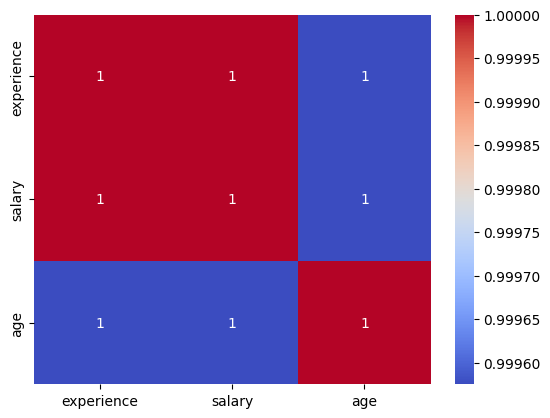

In [ ]:
# 3. Plot correlation heatmap (optional, for exams/projects)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# MAE (MEAN ABSOLUTE ERROR)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# MSE (Mean Squared Error)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

📌 What is R² Score?

R² (R-Squared), also called Coefficient of Determination, is a metric used to evaluate how well a regression model fits the data.

It tells us how much of the variation in the target variable (y) is explained by the model.

🔥 Intuition

If R² = 1.0 → 100% accuracy
The model perfectly predicts the output.
If R² = 0.0 → 0% accuracy

The model does not explain any variation — same as guessing the mean of y.
If R² = negative

The model is worse than guessing the mean.
📌 Formula (conceptual understanding)
𝑅2=1− (Sum of squared prediction errors / Sum of squared errors from the mean)


In simple words:

R² = 1 - (Error of model / Error if we guessed average value)

🔍 Example Interpretation
R² Score	Meaning
1	Perfect fit
0.9	Model explains 90% of variation → Very good
0.5	Model explains 50% variation → Moderate
0.0	Model explains nothing
< 0	The model is worse than taking the mean
💡 Real-life analogy

Imagine you try to predict someone's marks based on hours studied.

If R² = 0.95 → "95% of difference in marks can be explained by hours studied"

If R² = 0.20 → "Only 20% of variation can be explained; many other factors affect marks"

# R^2 CODE

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

## KNN (K-Nearest Neighbors)

In [ ]:
data_classification = {
    'height': [150, 152, 158, 160, 165, 170, 172, 175, 180, 185],
    'weight': [45, 48, 52, 54, 60, 65, 70, 72, 80, 85],
    'fitness': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]    # 0 = Unfit, 1 = Fit
}

df = pd.DataFrame(data_classification)
print(df)

   height  weight  fitness
0     150      45        0
1     152      48        0
2     158      52        0
3     160      54        0
4     165      60        1
5     170      65        1
6     172      70        1
7     175      72        1
8     180      80        1
9     185      85        1


In [ ]:
X = df[['height','weight']]
y = df['fitness']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0
